In [1]:
import graphical_sampling as gs
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from scipy.spatial import ConvexHull, QhullError

In [2]:
N = 144
n = 4

cluster_data = np.loadtxt('populations2/clust_N144_perm.csv', delimiter=",", skiprows=1)
cluster_pop_eq = gs.Population(coords=cluster_data[:, :2], inclusions=np.full(N, n/N), n=4)
cluster_pop_un = gs.Population(coords=cluster_data[:, :2], inclusions=cluster_data[:, 2], n=4)

grid_data = np.loadtxt('populations2/grid_N144_perm.csv', delimiter=",", skiprows=1)
grid_pop_eq = gs.Population(coords=grid_data[:, :2], inclusions=np.full(N, n/N), n=4)
grid_pop_un = gs.Population(coords=grid_data[:, :2], inclusions=grid_data[:, 2], n=4)

rand_data = np.loadtxt('populations2/rand_N144_perm.csv', delimiter=",", skiprows=1)
rand_pop_eq = gs.Population(coords=rand_data[:, :2], inclusions=np.full(N, n/N), n=4)
rand_pop_un = gs.Population(coords=rand_data[:, :2], inclusions=rand_data[:, 2], n=4)

pops = [
    cluster_pop_eq, grid_pop_eq, rand_pop_eq, cluster_pop_un, grid_pop_un, rand_pop_un
]

In [3]:
# for pop in pops:
#     fbn = gs.clustering.IPBalancedOTNMeans(n)
#     fbn.fit(pop)
#     ax = fbn.plot(mode='hard', ax=ax)

In [12]:
def plot(
        row: int,
        column: int,
        row_title: str,
        column_title: str,
        color_order: list,
        fbn,
        ax: plt.Axes | None = None,
        background_gdf=None,
        show_centroids: bool = False,
        connect_centroids: bool = False,
        size_scale: float = 1000.0,
        figsize: tuple[int, int] = (8, 6),
        dpi: int = 100,
        show_zone_sub_hulls: bool = True,
        show_zone_labels: bool = True
) -> plt.Axes:

    def _draw_hull(points: np.ndarray, color: str, alpha: float, edge_color: str, lw: float):
        if points.shape[0] < 3:
            return None
        try:
            hull = ConvexHull(points)
            vertices = points[hull.vertices]
        except (QhullError, ValueError):
            return None
        ax.add_patch(Polygon(vertices, closed=True, facecolor=color, alpha=alpha,
                                edgecolor=edge_color, lw=lw, zorder=1))
        return vertices.mean(axis=0)

    def _draw_zone_centroid_label(points: np.ndarray, label: int):
        if points.shape[0] == 0:
            return
        # Use geometric mean of all points in the zone
        centroid = points.mean(axis=0)
        ax.text(centroid[0], centroid[1], str(label+1),
                size=20, weight='bold', color='black',
                horizontalalignment='center', verticalalignment='center', zorder=10)

    def _draw_border_to_cluster_connections(linewidth: float = 3.0, alpha: float = 0.9):
        # Map each border point -> list of clusters that contain it as border
        border_to_clusters = {}

        for cluster_idx, c_data in enumerate(formatted_soft_cluster_data):
            for b in c_data['border_points']['indices']:
                border_to_clusters.setdefault(int(b), []).append(cluster_idx)

        for border_idx, cluster_ids in border_to_clusters.items():
            # If data are clean, this should usually be exactly two clusters
            if len(cluster_ids) < 2:
                continue

            border_pt = fbn.pop.coords[border_idx]

            for cluster_idx in cluster_ids[:2]:
                c_data = formatted_soft_cluster_data[cluster_idx]
                cluster_color = c_data['parent_color']

                # Prefer free points for nearest representative
                candidate_indices = c_data['free_points']['indices']

                # Fallback: if no free points exist, use all non-border points from zones
                if candidate_indices.size == 0 and c_data['zones']:
                    candidate_indices = np.unique(
                        np.concatenate([z['indices'] for z in c_data['zones'] if len(z['indices']) > 0])
                    )

                # Final fallback: skip if still empty
                if candidate_indices.size == 0:
                    continue

                candidate_pts = fbn.pop.coords[candidate_indices]
                dists = np.linalg.norm(candidate_pts - border_pt, axis=1)
                nearest_idx = candidate_indices[np.argmin(dists)]
                nearest_pt = fbn.pop.coords[nearest_idx]

                ax.plot(
                    [border_pt[0], nearest_pt[0]],
                    [border_pt[1], nearest_pt[1]],
                    color=cluster_color,
                    linewidth=linewidth,
                    alpha=alpha,
                    solid_capstyle='round',
                    zorder=2.7,  # below black border points, above hulls
                )


    if ax is None:
        _, ax = plt.subplots(figsize=figsize, dpi=dpi)

    if background_gdf is not None:
        background_gdf.plot(ax=ax, color="white", edgecolor="black", linewidth=1.5, zorder=0)

    # Structure data list (adjusted to handle zones)
    formatted_hard_cluster_data = []
    formatted_soft_cluster_data = []

    if fbn.labels is None:
        raise ValueError("Model not fitted yet.")
    for i in range(fbn.n):
        idx = np.where(fbn.labels == i)[0]
        formatted_hard_cluster_data.append({
            'parent_color': None,  # assigned later
            'free_points': {'indices': idx, 'shares': np.ones(len(idx), dtype=float)},
            'border_points': {'indices': np.array([], dtype=int), 'shares': np.array([], dtype=float)},
            'zones': []
        })

    if fbn.clusters is None:
        raise ValueError("Model not fitted yet.")
    for cluster in fbn.clusters:
        # 1. Identify "Internal" (free) points of the parent cluster
        # In your fit_zones logic, these are the original IDs minus parent borders.
        zone_ids = [idx for z in cluster.zones for idx in z.indices]
        free_ids = np.array(zone_ids, dtype=int)

        # 2. Extract border info (remains untouched by zones)
        border_indices = []
        border_shares = []
        if cluster.floor.index != -1 and cluster.floor.percentage > 1e-9:
            border_indices.append(cluster.floor.index)
            border_shares.append(cluster.floor.percentage)
        if cluster.ceil.index != -1 and cluster.ceil.percentage > 1e-9:
            border_indices.append(cluster.ceil.index)
            border_shares.append(cluster.ceil.percentage)

        # 3. Handle specific zone-level points (subpopulation indices)
        zones_list = []
        # Only use individual zone details if fit_zones was actually called (len > 1)
        # and we want to draw sub-convex hulls.
        if len(cluster.zones) > 1 and show_zone_sub_hulls:
            for zone_index, z in enumerate(cluster.zones):
                z_indices = np.array(z.indices, dtype=int)
                zones_list.append({
                    'indices': z_indices,
                    'shares': np.ones(len(z_indices), dtype=float),
                    'label': zone_index
                })

        formatted_soft_cluster_data.append({
            'parent_color': None,
            'free_points': {'indices': free_ids, 'shares': np.ones(len(free_ids), dtype=float)},
            'border_points': {'indices': np.array(border_indices, dtype=int),
                                'shares': np.array(border_shares, dtype=float)},
            'zones': zones_list
        })

    k = len(formatted_soft_cluster_data)

    # 1. Calculate Weighted Centroids (used for color sorting AND plotting)
    centroids = np.full((k, 2), np.nan, float)
    centroids2 = np.full((k, 2), np.nan, float)

    for i, c_data in enumerate(formatted_hard_cluster_data):
        all_indices = np.concatenate([c_data['free_points']['indices'], c_data['border_points']['indices']])
        if len(all_indices) == 0:
            continue
        pts = fbn.pop.coords[all_indices]
        centroids[i] = pts.mean(axis=0)

    for i, c_data in enumerate(formatted_soft_cluster_data):
        all_indices = np.concatenate([c_data['free_points']['indices'], c_data['border_points']['indices']])
        if len(all_indices) == 0: continue

        all_shares = np.concatenate([c_data['free_points']['shares'], c_data['border_points']['shares']])

        pts = fbn.pop.coords[all_indices]
        # Probabilities must be adjusted by sharing weights
        adjusted_probs = fbn.pop.inclusions[all_indices] * all_shares
        s = float(adjusted_probs.sum())
        centroids2[i] = (pts * adjusted_probs[:, None]).sum(axis=0) / s if s > 0 else pts.mean(axis=0)

    # 2. Spatial Color Assignment (Lexicographical sort)
    palette_seq = [
        "#59A14F", "#E15759", "#1F77B4", "#FDD835",
        "#9467BD", "#8C564B", "#17BECF", "#FF7F0E", "#56B4E9",
        "#EF5350", "#CC79A7", "#FBC02D", "#7F3C8D", "#11A579",
        "#EF5350", "#FFC107"
    ]

    # Sort spatially (Top-to-bottom, left-to-right)
    order = np.lexsort((centroids2[:, 0], -centroids2[:, 1]))

    order[[0, 1, 2, 3]] = order[color_order[row][column]]

    for rank, idx in enumerate(order):
        if rank < len(palette_seq):
            formatted_soft_cluster_data[idx]['parent_color'] = palette_seq[rank % len(palette_seq)]
        else:
            formatted_soft_cluster_data[idx]['parent_color'] = "#808080"  # Fallback

    # 3. Draw Clusters and Zones
    for i, c_data in enumerate(formatted_soft_cluster_data):
        c = c_data['parent_color']
        if c is None: continue  # Skip empty/invalid clusters

        # --- Draw Internal Points and Soft Hull ---
        # Use all relevant indices for the main hull
        all_indices = np.concatenate([c_data['free_points']['indices'], c_data['border_points']['indices']])
        coords = fbn.pop.coords[all_indices]
        all_shares = np.concatenate([c_data['free_points']['shares'], c_data['border_points']['shares']])
        probs = fbn.pop.inclusions[all_indices] * all_shares

        c_data_hard = formatted_hard_cluster_data[i]
        coords_hard = fbn.pop.coords[all_indices]
        all_indices_hard = np.concatenate([c_data_hard['free_points']['indices'], c_data_hard['border_points']['indices']])
        all_shares_hard = np.concatenate([c_data_hard['free_points']['shares'], c_data_hard['border_points']['shares']])
        probs_hard = fbn.pop.inclusions[all_indices_hard] * all_shares_hard

        is_border = np.isin(all_indices, c_data['border_points']['indices'])

        # The overall structure (Soft border shape) is drawn first (Lowest Z-order)
        if row == 1:
            _draw_hull(coords[~is_border], color=c, alpha=0.15, edge_color="black", lw=1.0)
        else:
            _draw_hull(coords, color=c, alpha=0.15, edge_color="black", lw=1.0)

        # --- Draw Internal Zones ---
        if c_data['zones']:
            # Plot internal sub-hulls to visualize fit_zones segmentation
            for zone in c_data['zones']:
                if zone['indices'].size > 0:
                    zone_coords = fbn.pop.coords[zone['indices']]
                    # Sub-hulls use slightly more opacity to differentiate them
                    _draw_hull(zone_coords, color=c, alpha=0.35, edge_color="none", lw=0.0)

                    if show_zone_labels:
                        _draw_zone_centroid_label(zone_coords, zone['label'])

        # --- Draw Points ---
        sizes = probs * size_scale

        # Free points of the parent cluster
        if row == 1:
            ax.scatter(coords[~is_border, 0], coords[~is_border, 1],
                        s=sizes[~is_border], color=c,
                        edgecolors="none", alpha=1.0, zorder=2)
            # Border points (Black) - Highest Z-order for points
            ax.scatter(coords[is_border, 0], coords[is_border, 1],
                        s=sizes[is_border], color="black", marker='^',
                        edgecolors="none", alpha=1.0, zorder=3)

            _draw_border_to_cluster_connections(linewidth=2, alpha=0.2)

        else:
            ax.scatter(coords[:, 0], coords[:, 1],
                        s=sizes, color=c,
                        edgecolors="none", alpha=1.0, zorder=2)

        ax.text(
            *(centroids[i]-np.array([0.05, -0.02])).T,
            s=f'{probs_hard.sum():.2f}',
            fontsize=7,
            fontweight='bold',
            bbox=dict(
                facecolor='white',
                alpha=0.5,
                pad=1.0,
                edgecolor='none'
            )
        )

        ax.text(
            *(centroids[i]-np.array([0.05, 0.03])).T,
            s=f'{probs.sum():.2f}',
            fontsize=7,
            fontweight='bold',
            color='white',
            bbox=dict(
                facecolor='black',
                alpha=0.3,
                pad=1.0,
                edgecolor='none'
            )
        )


    # 4. Handle Centroids Visuals (drawn based on parent centroids)
    if connect_centroids and len(centroids) > 1:
        ax.plot(centroids[:, 0], centroids[:, 1],
                color="black", linestyle="--", linewidth=1.5, alpha=0.7, zorder=4)

    if show_centroids and len(centroids) > 0:
        ax.scatter(centroids[:, 0], centroids[:, 1],
                    marker="^", color="black", s=80, zorder=5, label="Centroids")

    ax.set_aspect("equal")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    if row == 1:
        ax.set_xticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0], ['0.0', '0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=8)

    else:
        ax.set_xticklabels([])
    if column == 0:
        ax.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0], ['0.0', '0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=8)
        ax.annotate(row_title, xy=(-0.25, 0.5), xycoords='axes fraction',
                va='center', rotation=90, fontweight='bold')
    else:
        ax.set_yticklabels([])

    if row == 0:
        ax.annotate(column_title, xy=(0.5, 1.05), xycoords='axes fraction',
                ha='center', fontweight='bold')

    return ax

In [13]:
def plot_population_grid(populations, titles, color_order, n, figsize=(10, 6)):
    """
    Create a mega-plot grid for clustering populations.

    Parameters
    ----------
    populations : list[list[Population]]
        Nested list where each inner list corresponds to a row of populations.
    n : int
        Number of clusters for IPBalancedOTNMeans.
    figsize : tuple
        Matplotlib figure size.

    Returns
    -------
    fig, axes
    """

    n_rows = len(populations)
    n_cols = max(len(row) for row in populations)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize, squeeze=False)

    for i, row in enumerate(populations):
        for j, pop in enumerate(row):
            ax = axes[i, j]

            fbn = gs.clustering.IPBalancedOTNMeans(n, n_init=10)
            fbn.fit(pop)
            print()
            plot(i, j, titles[i][j][0], titles[i][j][1], color_order, fbn, ax=ax, size_scale=500)

        # hide unused axes if row shorter than max columns
        for j in range(len(row), n_cols):
            axes[i, j].axis("off")

    plt.tight_layout()
    return fig


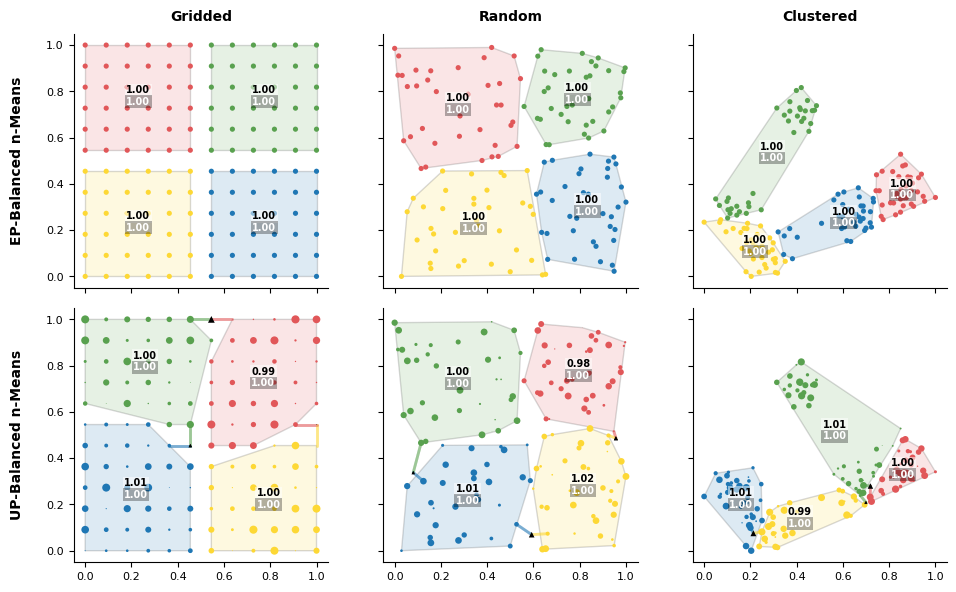

In [20]:
pops = [
    [grid_pop_eq, rand_pop_eq, cluster_pop_eq],
    [grid_pop_un, rand_pop_un, cluster_pop_un]
]
titles = [
    [['EP-Balanced n-Means', 'Gridded'], ['', 'Random'], ['', 'Clustered']],
    [['UP-Balanced n-Means', ''], ['', ''], ['', '']],
]
color_order = [
    [
        [0, 1, 2, 3],
        [0, 1, 2, 3],
        [0, 1, 2, 3]
    ],
    [
        [0, 1, 2, 3],
        [1, 0, 3, 2],
        [0, 1, 2, 3]
    ]
]
fig = plot_population_grid(pops, titles, color_order, n=4)
fig.savefig('clusters.pdf')